# Section 5.1

## Example 5.1.1

Here are some points that we could consider to be observations of an unknown function on $[-1,1]$.

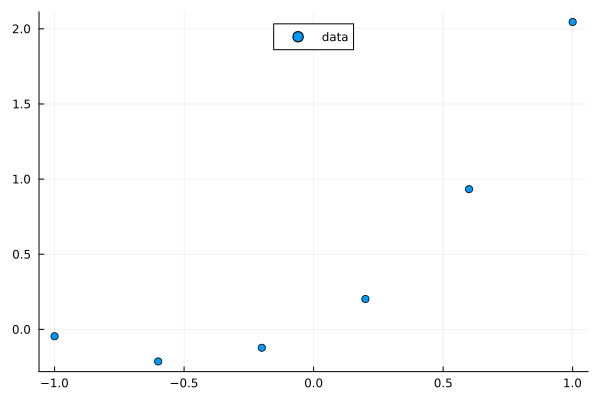

In [1]:
using Plots
n = 5
t = range(-1, 1, n+1)
y = @. t^2 + t + 0.05 * sin(20t)
scatter(t, y, label="data", legend=:top)

```{index} ! Julia; fit
```

The polynomial interpolant, as computed using `fit`, looks very sensible. It's the kind of function you'd take home to meet your parents.

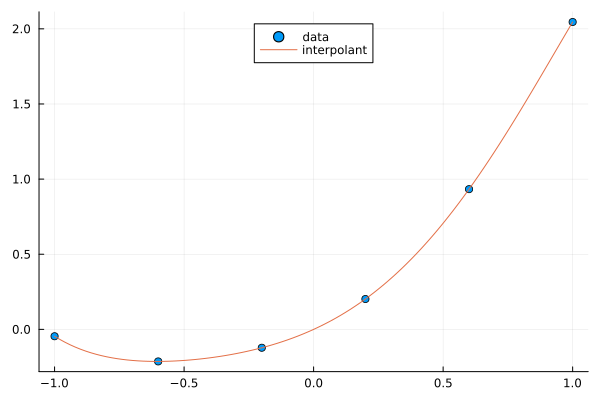

In [2]:
using Polynomials
p = Polynomials.fit(t, y, n)     # interpolating polynomial
plot!(p, -1, 1, label="interpolant")

But now consider a different set of points generated in almost exactly the same way.

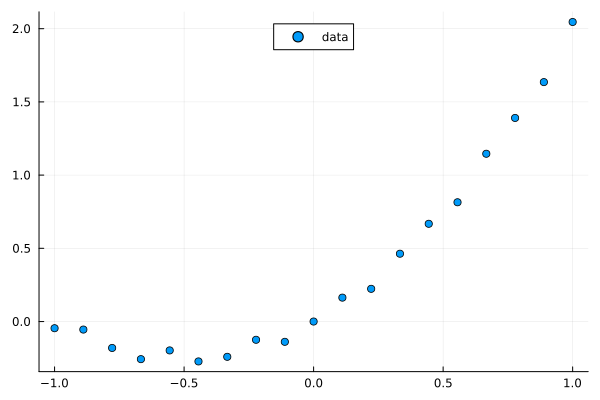

In [3]:
n = 18
t = range(-1, 1, n+1)
y = @. t^2 + t + 0.05 * sin(20t)
scatter(t, y, label="data", leg=:top)

The points themselves are unremarkable. But take a look at what happens to the polynomial interpolant.

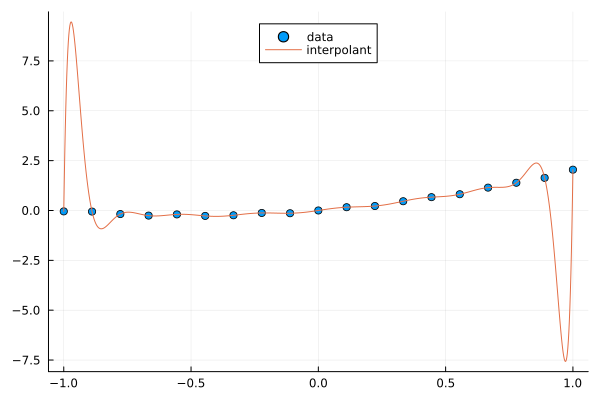

In [4]:
p = Polynomials.fit(t, y, n)
x = range(-1, 1, 1000)    # use a lot of points
plot!(x, p.(x), label="interpolant")

Surely there must be functions that are more intuitively representative of those points!


## Example 5.1.3


Let us recall the data from @demo-interpolation-global.

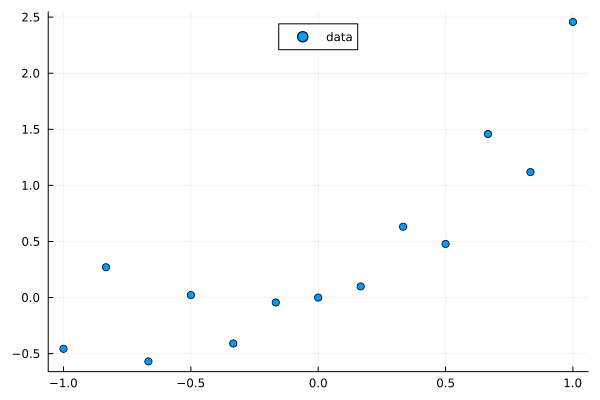

In [14]:
using Plots
n = 12
t = range(-1, 1, n+1)
y = @. t^2 + t + 0.5 * sin(20t)
scatter(t, y, label="data", leg=:top)

Here is an interpolant that is linear between each consecutive pair of nodes, using `plinterp` from {numref}`section-localapprox-pwlin`.

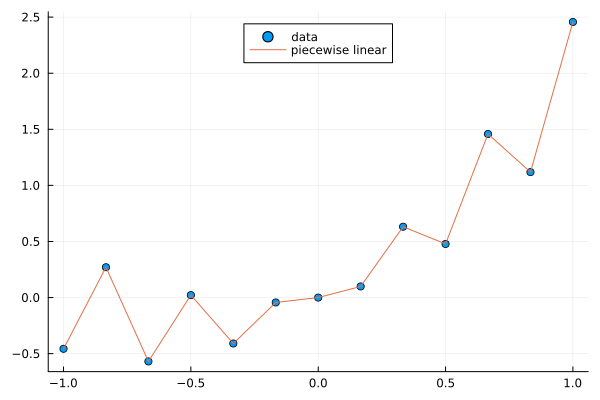

In [15]:
using FNCFunctions
p = FNC.plinterp(t, y)
plot!(p, -1, 1, label="piecewise linear")

```{index} ! Julia; Spline1D
```

We may prefer a smoother interpolant that is piecewise cubic, generated using `Spline1D` from the `Dierckx` package.

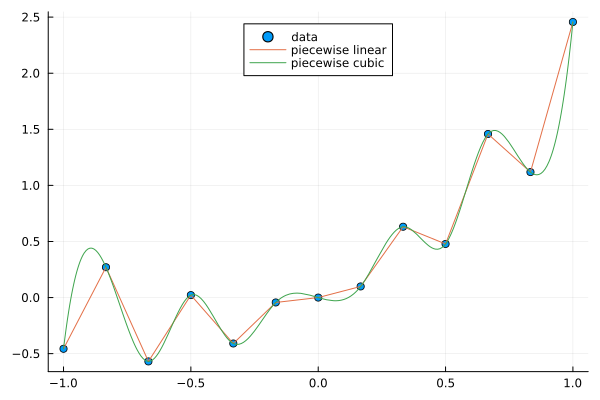

In [16]:
using Dierckx
p = Spline1D(t, y)
plot!(x -> p(x), -1, 1, label="piecewise cubic")

## Example 5.1.4

In @demo-interpolation-pwise we saw a big difference between polynomial interpolation and piecewise polynomial interpolation of some arbitrarily chosen data. The same effects can be seen clearly in the cardinal functions, which are closely tied to the condition numbers.

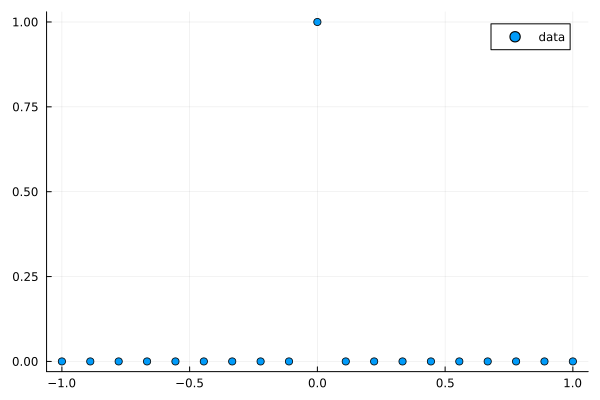

In [21]:
using Plots, LaTeXStrings

n = 18
t = range(-1, 1, n+1)
y = [zeros(9); 1; zeros(n - 9)];  # data for 10th cardinal function

scatter(t, y, label="data")

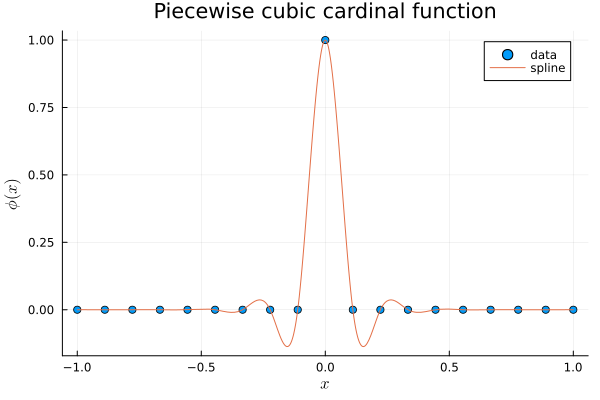

In [22]:
using Dierckx
ϕ = Spline1D(t, y)
plot!(x -> ϕ(x), -1, 1;
    label="spline",
    xlabel=L"x",  ylabel=L"\phi(x)",
    title="Piecewise cubic cardinal function")

The piecewise cubic cardinal function is nowhere greater than one in absolute value. This happens to be true for all the cardinal functions, ensuring a good condition number for any interpolation with these functions. But the story for global polynomials is very different.

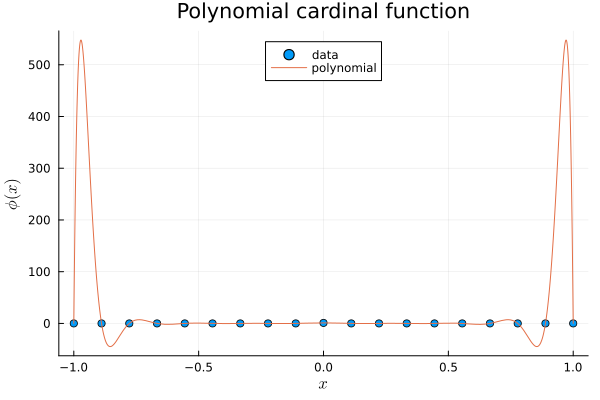

In [23]:
using Polynomials

scatter(t, y, label="data")

ϕ = Polynomials.fit(t, y, n)
plot!(x -> ϕ(x), -1, 1;
    label="polynomial",  legend=:top,
    xlabel=L"x",  ylabel=L"\phi(x)", 
    title="Polynomial cardinal function")

From the figure we can see that the condition number for polynomial interpolation on these nodes is at least 500.